<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sagnik/FedMD_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedMD: Heterogeneous Federated Learning via Model Distillation

## Overview

In traditional Federated Learning algorithms such as **FedAvg**, participating clients collaboratively train a global model by repeatedly exchanging model parameters with a central server. This approach assumes that all clients share the same model architecture, making parameter averaging feasible.

However, in many real-world applications, different devices possess varying computational capabilities, memory constraints, and hardware specifications. As a result, enforcing a single neural network architecture across all clients is often impractical.

To address this limitation, **FedMD (Federated Model Distillation)**, proposed by Li and Wang (NeurIPS 2019), enables collaborative learning among **heterogeneous models** without exchanging model parameters.

Instead of sharing weights or gradients, clients communicate only the **raw logits (class scores before softmax)** generated on a shared public dataset. The server aggregates these logits to produce a consensus, which is then used to guide each client's learning through knowledge distillation.

This notebook implements the original FedMD algorithm as described in the paper, following each stage of the methodology as closely as possible.

---

## Objectives

In this notebook, we will:

- Implement the original FedMD algorithm.
- Simulate Federated Learning with **5 heterogeneous clients**.
- Use **MNIST** as the benchmark dataset.
- Split the training data into:
  - **20% Public Dataset**
  - **80% Private Dataset**
- Partition the private data using a **Dirichlet distribution (α = 0.5)** to create statistical heterogeneity.
- Train heterogeneous neural network architectures collaboratively using model distillation.
- Evaluate the performance of each client after every communication round.
- Visualize the learning behavior throughout federated training.

---

## FedMD Workflow

The implementation follows the original paper and consists of three major phases:

### Phase 1 — Public Pre-training

Each client independently trains its own model on the labeled public dataset.

### Phase 2 — Private Fine-tuning

Each client fine-tunes its model using only its own private local dataset.

### Phase 3 — Collaborative Training

For every communication round:

1. Each client computes **raw logits** on the shared public dataset.
2. The server averages these logits to form a consensus.
3. The consensus logits are broadcast back to every client.
4. Clients perform the **Digest** phase by matching their logits to the consensus using Mean Squared Error (MSE).
5. Clients perform the **Revisit** phase by training again on their private labeled data.
6. Each client's performance is evaluated on the test dataset.

Unlike FedAvg, **no model parameters or gradients are exchanged during training**.

---

## Experimental Configuration

| Parameter | Value |
|-----------|------:|
| Dataset | MNIST |
| Public Dataset | 20% |
| Private Dataset | 80% |
| Number of Clients | 5 |
| Dirichlet α | 0.5 |
| Communication Rounds | 20 |
| Local Epochs | 2 |
| Digest Epochs | 1 |
| Batch Size | 128 |
| Optimizer | Adam |
| Learning Rate | 0.001 |

---

## Expected Outcome

By the end of this notebook, we will have a complete implementation of the FedMD algorithm that closely follows the original NeurIPS 2019 paper and demonstrates how heterogeneous neural network architectures can collaboratively learn through knowledge distillation without exchanging model parameters.

In [ ]:
# FedMD: Heterogeneous Federated Learning via Model Distillation
# =============================================================
#
# This notebook follows the original FedMD paper:
#
# Li, D., Wang, J.
# "FedMD: Heterogeneous Federated Learning via Model Distillation"
# NeurIPS Workshop, 2019
#
# The notebook is organized into modular sections.
# Execute the notebook sequentially from top to bottom.

# 2. Imports & Configuration

In this section, we import all the libraries required for implementing the FedMD algorithm and define the experimental configuration.

The imported libraries serve different purposes:

- **PyTorch** is used for building and training neural network models.
- **Torchvision** provides the MNIST dataset and commonly used image transformations.
- **NumPy** is used for numerical computations and reproducibility.
- **Matplotlib** and **Seaborn** are used for visualizing the experimental results.
- **Scikit-learn** provides utilities for data splitting and evaluation.

We also define all experiment hyperparameters in a single configuration block. Keeping these values centralized makes the notebook easier to modify and ensures reproducibility.

The configuration used in this notebook follows the experimental setup described in the FedMD paper:

- Dataset: MNIST
- Number of clients: 5
- Dirichlet α = 0.5
- Communication rounds = 20
- Local epochs = 2
- Digest epochs = 1
- Optimizer = Adam
- Learning rate = 0.001

Finally, the notebook automatically detects whether a CUDA-enabled GPU is available. If so, all models and tensors will be trained on the GPU; otherwise, the CPU will be used.

In [ ]:
# ============================================================
# Imports
# ============================================================

import copy
import random
import time
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import (
    DataLoader,
    Dataset,
    Subset,
)

from torchvision import datasets, transforms, models

from sklearn.model_selection import train_test_split

# Better plot aesthetics
plt.style.use("ggplot")
sns.set_context("notebook")

# ============================================================
# Reproducibility
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ============================================================
# Experiment Configuration
# ============================================================

NUM_CLIENTS = 5

NUM_ROUNDS = 15

LOCAL_EPOCHS = 2

DIGEST_EPOCHS = 1

BATCH_SIZE = 128

LEARNING_RATE = 1e-3

DIRICHLET_ALPHA = 0.5

PUBLIC_RATIO = 0.20

NUM_CLASSES = 10

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("FedMD Experimental Configuration")
print("=" * 60)

print(f"Device              : {DEVICE}")
print(f"Clients             : {NUM_CLIENTS}")
print(f"Communication Rounds: {NUM_ROUNDS}")
print(f"Local Epochs        : {LOCAL_EPOCHS}")
print(f"Digest Epochs       : {DIGEST_EPOCHS}")
print(f"Batch Size          : {BATCH_SIZE}")
print(f"Learning Rate       : {LEARNING_RATE}")
print(f"Dirichlet Alpha     : {DIRICHLET_ALPHA}")
print(f"Public Ratio        : {PUBLIC_RATIO}")
print(f"Random Seed         : {SEED}")

FedMD Experimental Configuration
Device              : cuda
Clients             : 5
Communication Rounds: 15
Local Epochs        : 2
Digest Epochs       : 1
Batch Size          : 128
Learning Rate       : 0.001
Dirichlet Alpha     : 0.5
Public Ratio        : 0.2
Random Seed         : 42


# 3. Loading the MNIST Dataset

The FedMD algorithm requires two types of data:

1. A **training dataset**, from which we will later create:
   - a **public dataset** shared among all clients, and
   - **private datasets** owned individually by each client.
2. A **test dataset**, used only for evaluating the models throughout federated training.

In this notebook, we use the **MNIST** handwritten digit dataset, one of the most widely used benchmarks for image classification.

### About MNIST

MNIST consists of grayscale images of handwritten digits (0–9).

| Property | Value |
|----------|-------|
| Image Size | 28 × 28 |
| Channels | 1 |
| Number of Classes | 10 |
| Training Images | 60,000 |
| Test Images | 10,000 |

Since all models should receive inputs in a consistent format, we apply a simple preprocessing pipeline:

- Convert each image to a PyTorch tensor.
- Normalize pixel values using the standard MNIST mean and standard deviation.

At this stage, **no federated partitioning is performed**. We simply load the complete dataset into memory. The public/private split and the client-specific partitioning will be performed in the following sections.

100%|██████████| 9.91M/9.91M [00:00<00:00, 58.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.77MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.2MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]


MNIST Dataset Loaded
Training Samples : 60,000
Test Samples     : 10,000
Number of Classes: 10


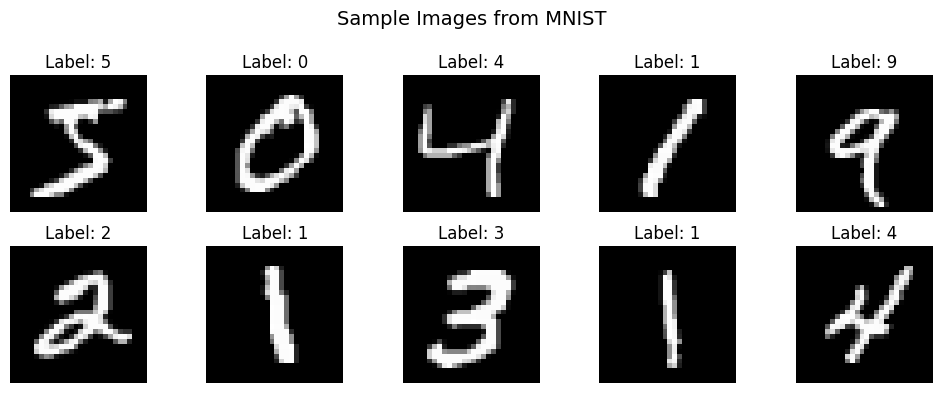

In [ ]:
# ============================================================
# Load MNIST Dataset
# ============================================================

# Image preprocessing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Training dataset (will later be split into public and private)
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

# Test dataset (used only for evaluation)
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("=" * 60)
print("MNIST Dataset Loaded")
print("=" * 60)

print(f"Training Samples : {len(train_dataset):,}")
print(f"Test Samples     : {len(test_dataset):,}")
print(f"Number of Classes: {NUM_CLASSES}")

# ------------------------------------------------------------
# Display sample images
# ------------------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("Sample Images from MNIST", fontsize=14)
plt.tight_layout()
plt.show()

# 4. Public / Private Dataset Split

Unlike traditional Federated Learning algorithms such as FedAvg, FedMD assumes the existence of a **small public dataset** that is accessible to all participating clients.

This public dataset serves as the medium through which knowledge is exchanged. During collaborative training, clients generate predictions (raw logits) on this shared data, and the server aggregates these predictions to create a consensus. Importantly, **only the logits are shared**—the public dataset itself is never modified or redistributed.

The remaining training data is treated as **private data**. Each client will later receive a different subset of this private data using a Dirichlet distribution to simulate statistical heterogeneity.

For this implementation, we follow the experimental setup:

- **Public Dataset:** 20% of the MNIST training set
- **Private Dataset:** 80% of the MNIST training set

To ensure reproducibility, the split is performed using a fixed random seed.

At the end of this section, we will have:

- A shared public dataset.
- A private dataset that will later be partitioned among the five clients.

In [ ]:
# ============================================================
# Public / Private Dataset Split
# ============================================================

num_train = len(train_dataset)

num_public = int(PUBLIC_RATIO * num_train)
num_private = num_train - num_public

# Generate shuffled indices
indices = np.random.permutation(num_train)

public_indices = indices[:num_public]
private_indices = indices[num_public:]

# Create dataset subsets
public_dataset = Subset(train_dataset, public_indices)
private_dataset = Subset(train_dataset, private_indices)

print("=" * 60)
print("Public / Private Dataset Split")
print("=" * 60)

print(f"Total Training Samples : {num_train:,}")
print(f"Public Samples         : {len(public_dataset):,}")
print(f"Private Samples        : {len(private_dataset):,}")

print(f"\nPublic Ratio  : {len(public_dataset)/num_train:.2%}")
print(f"Private Ratio : {len(private_dataset)/num_train:.2%}")

Public / Private Dataset Split
Total Training Samples : 60,000
Public Samples         : 12,000
Private Samples        : 48,000

Public Ratio  : 20.00%
Private Ratio : 80.00%


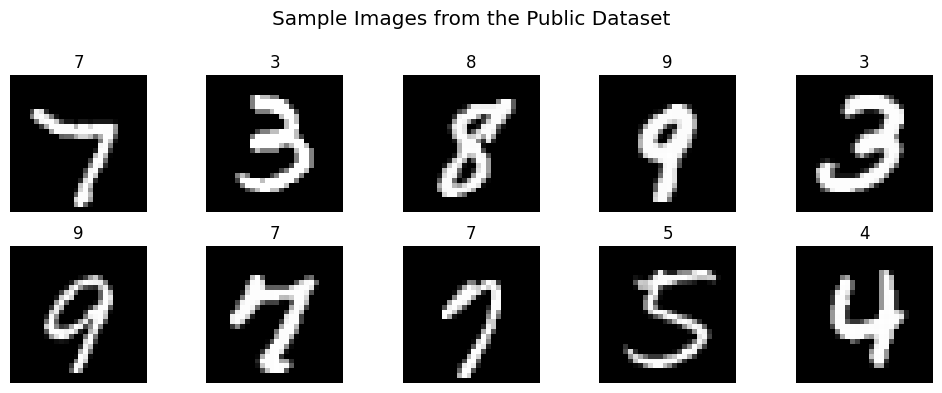

In [ ]:
# ============================================================
# Verify the Split
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, idx in zip(axes.flat, public_indices[:10]):
    image, label = train_dataset[idx]
    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"{label}")
    ax.axis("off")

plt.suptitle("Sample Images from the Public Dataset")
plt.tight_layout()
plt.show()

# 5. Federated Private Data Partitioning

After creating the shared public dataset, the remaining training samples form the **private dataset**. In a federated learning environment, this private data is distributed among multiple clients.

Rather than splitting the data equally or randomly, we partition it using a **Dirichlet distribution**, which is a widely adopted approach for simulating statistical heterogeneity in Federated Learning.

## Why Use a Dirichlet Distribution?

In real-world federated systems, different users naturally possess different types of data. For example:

- One phone may contain mostly images of cats.
- Another may contain mostly cars.
- Another may rarely observe certain classes.

Such non-identically distributed (non-IID) data significantly affects federated optimization.

The Dirichlet distribution allows us to control this heterogeneity using a single parameter, **α (alpha)**.

- Large α → Nearly IID distribution
- Small α → Highly heterogeneous distribution

In this notebook, we use:

**α = 0.5**

which produces a moderately heterogeneous data distribution.

## Partitioning Procedure

For each class separately:

1. Collect all samples belonging to that class.
2. Shuffle the samples.
3. Draw client proportions from a Dirichlet distribution.
4. Allocate the class samples according to these proportions.
5. Repeat for every class.

At the end of this process:

- Every sample belongs to exactly one client.
- Different clients own different class distributions.
- The server never accesses these client datasets during training.

The resulting client datasets will be used throughout the remainder of the FedMD implementation.

In [ ]:
# ============================================================
# Dirichlet Partition of the Private Dataset
# ============================================================

def dirichlet_partition(dataset, num_clients, alpha, seed=42):
    """
    Partition a dataset among clients using a Dirichlet distribution.

    Parameters
    ----------
    dataset : torch.utils.data.Subset
        Private dataset.

    num_clients : int
        Number of clients.

    alpha : float
        Dirichlet concentration parameter.

    seed : int
        Random seed.

    Returns
    -------
    client_indices : list
        List of sample indices for every client.
    """

    np.random.seed(seed)

    # Labels of samples inside the private dataset
    labels = np.array([
        dataset.dataset.targets[idx].item()
        for idx in dataset.indices
    ])

    client_indices = [[] for _ in range(num_clients)]

    # Partition each class independently
    for class_id in range(NUM_CLASSES):

        class_mask = np.where(labels == class_id)[0]

        np.random.shuffle(class_mask)

        proportions = np.random.dirichlet(
            np.repeat(alpha, num_clients)
        )

        split_points = (
            np.cumsum(proportions) * len(class_mask)
        ).astype(int)[:-1]

        split_indices = np.split(class_mask, split_points)

        for client_id, idx in enumerate(split_indices):
            original_indices = [
                dataset.indices[i]
                for i in idx
            ]
            client_indices[client_id].extend(original_indices)

    return client_indices


# ------------------------------------------------------------
# Perform the partition
# ------------------------------------------------------------

client_indices = dirichlet_partition(
    dataset=private_dataset,
    num_clients=NUM_CLIENTS,
    alpha=DIRICHLET_ALPHA,
    seed=SEED,
)

print("=" * 60)
print("Dirichlet Partition Completed")
print("=" * 60)

total_samples = 0

for client_id, indices in enumerate(client_indices):

    total_samples += len(indices)

    print(
        f"Client {client_id + 1}: "
        f"{len(indices):5d} samples"
    )

print("-" * 60)
print(f"Total Assigned Samples: {total_samples}")

Dirichlet Partition Completed
Client 1: 14538 samples
Client 2:  6127 samples
Client 3: 10971 samples
Client 4:  9342 samples
Client 5:  7022 samples
------------------------------------------------------------
Total Assigned Samples: 48000


In [ ]:
# ============================================================
# Verify Every Sample Was Assigned Exactly Once
# ============================================================

assigned_indices = []

for indices in client_indices:
    assigned_indices.extend(indices)

print("=" * 60)
print("Partition Verification")
print("=" * 60)

print(f"Private Dataset Size : {len(private_dataset)}")
print(f"Assigned Samples     : {len(assigned_indices)}")
print(f"Unique Assigned      : {len(set(assigned_indices))}")

assert len(assigned_indices) == len(private_dataset)
assert len(set(assigned_indices)) == len(private_dataset)

print("\n✓ Every sample assigned exactly once.")

Partition Verification
Private Dataset Size : 48000
Assigned Samples     : 48000
Unique Assigned      : 48000

✓ Every sample assigned exactly once.


# 6. Visualizing Statistical Heterogeneity

After partitioning the private dataset, it is important to verify that the resulting client datasets are indeed statistically heterogeneous.

Since we used a Dirichlet distribution with **α = 0.5**, we expect different clients to contain different proportions of the ten digit classes.

Visualizing the class distribution helps us understand:

- how the data has been distributed among clients,
- whether some classes are overrepresented or underrepresented,
- the degree of statistical heterogeneity introduced by the Dirichlet partition.

In this section, we compute the number of samples belonging to each digit class for every client and visualize the results using:

- a summary table,
- a grouped bar chart,
- a heatmap.

These visualizations will also become useful later when comparing experiments with different values of the Dirichlet parameter α.

In [ ]:
# ============================================================
# Compute Class Distribution of Each Client
# ============================================================

client_class_counts = np.zeros(
    (NUM_CLIENTS, NUM_CLASSES),
    dtype=int
)

for client_id, indices in enumerate(client_indices):

    for idx in indices:
        label = train_dataset.targets[idx].item()
        client_class_counts[client_id, label] += 1

print("=" * 60)
print("Samples per Client and Class")
print("=" * 60)

header = "Client".ljust(10)

for c in range(NUM_CLASSES):
    header += f"{c:>6}"

header += f"{'Total':>10}"

print(header)

for client_id in range(NUM_CLIENTS):

    row = f"{client_id + 1}".ljust(10)

    for c in range(NUM_CLASSES):
        row += f"{client_class_counts[client_id, c]:>6}"

    row += f"{client_class_counts[client_id].sum():>10}"

    print(row)

Samples per Client and Class
Client         0     1     2     3     4     5     6     7     8     9     Total
1           1275  1026  2322  2564  2781  2304  1224   187   251   604     14538
2            940   555   401   696   575    92   115   330  1371  1052      6127
3           1888  2920   346     3   477  1468  2046     2   782  1039     10971
4            280   827   766   526   822   452  1275  2592   240  1562      9342
5            365    92   949  1123    11     1    81  1855  2047   498      7022


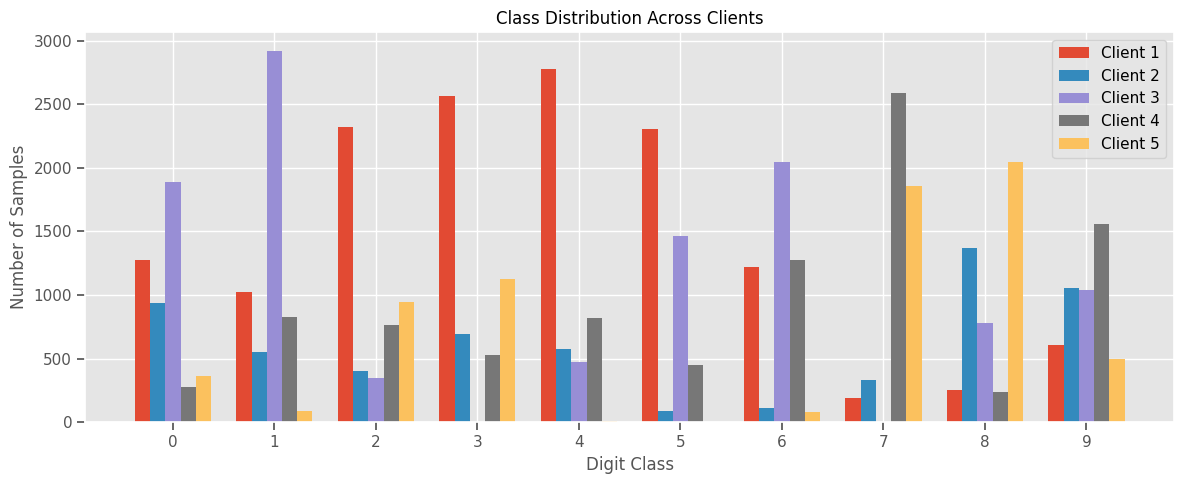

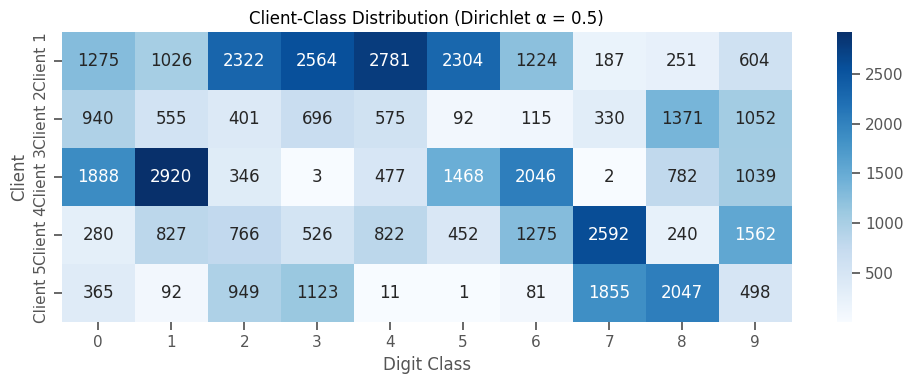

In [ ]:
# ============================================================
# Visualization of Client Class Distribution
# ============================================================

# ------------------------------------------------------------
# Grouped Bar Chart
# ------------------------------------------------------------

x = np.arange(NUM_CLASSES)
width = 0.15

plt.figure(figsize=(12, 5))

for client_id in range(NUM_CLIENTS):
    plt.bar(
        x + client_id * width,
        client_class_counts[client_id],
        width=width,
        label=f"Client {client_id + 1}"
    )

plt.xticks(
    x + width * (NUM_CLIENTS - 1) / 2,
    np.arange(NUM_CLASSES)
)

plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution Across Clients")
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Heatmap
# ------------------------------------------------------------

plt.figure(figsize=(10, 4))

sns.heatmap(
    client_class_counts,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=np.arange(NUM_CLASSES),
    yticklabels=[
        f"Client {i+1}"
        for i in range(NUM_CLIENTS)
    ]
)

plt.title("Client-Class Distribution (Dirichlet α = 0.5)")
plt.xlabel("Digit Class")
plt.ylabel("Client")
plt.tight_layout()
plt.show()

# 7. Creating Client DataLoaders

After partitioning the private dataset, each client now owns a unique subset of the training data.

In PyTorch, models are typically trained using **DataLoaders**, which efficiently load data in mini-batches, shuffle samples during training, and simplify the training loop.

In this section, we create:

- A **Subset** object for each client's private dataset.
- A corresponding **DataLoader** for each client.

Each client's DataLoader will be used during:

1. **Private Fine-tuning** (before collaborative learning).
2. **Revisit Phase** (after each Digest phase).

Each client trains **only on its own DataLoader**. No client can access another client's private data, preserving the federated learning setting.

The shared public dataset will be converted into its own DataLoader in the next section.

In [ ]:
# ============================================================
# Create Client Datasets and DataLoaders
# ============================================================

client_datasets = []
client_loaders = []

for client_id in range(NUM_CLIENTS):

    # Create a dataset for this client
    client_dataset = Subset(
        train_dataset,
        client_indices[client_id]
    )

    # Create DataLoader
    client_loader = DataLoader(
        client_dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available()
    )

    client_datasets.append(client_dataset)
    client_loaders.append(client_loader)

print("=" * 60)
print("Client DataLoaders Created")
print("=" * 60)

for client_id, dataset in enumerate(client_datasets):

    print(
        f"Client {client_id + 1}: "
        f"{len(dataset):5d} samples "
        f"({len(client_loaders[client_id])} batches)"
    )

Client DataLoaders Created
Client 1: 14538 samples (114 batches)
Client 2:  6127 samples (48 batches)
Client 3: 10971 samples (86 batches)
Client 4:  9342 samples (73 batches)
Client 5:  7022 samples (55 batches)


In [ ]:
# ============================================================
# Verify Client DataLoaders
# ============================================================

images, labels = next(iter(client_loaders[0]))

print("=" * 60)
print("Sample Batch from Client 1")
print("=" * 60)

print(f"Image Batch Shape : {images.shape}")
print(f"Label Batch Shape : {labels.shape}")

print(f"Labels in Batch:")
print(labels)

Sample Batch from Client 1
Image Batch Shape : torch.Size([128, 1, 28, 28])
Label Batch Shape : torch.Size([128])
Labels in Batch:
tensor([0, 4, 6, 6, 1, 1, 4, 4, 2, 4, 5, 4, 0, 4, 3, 5, 5, 3, 3, 3, 0, 4, 4, 2,
        1, 8, 4, 2, 5, 2, 3, 4, 5, 5, 4, 4, 3, 3, 1, 5, 4, 2, 6, 0, 5, 4, 9, 3,
        5, 3, 2, 1, 3, 6, 4, 7, 3, 4, 3, 6, 0, 3, 0, 0, 4, 1, 3, 2, 2, 5, 3, 0,
        4, 4, 4, 3, 6, 4, 5, 1, 6, 3, 3, 2, 4, 5, 4, 8, 1, 3, 2, 9, 0, 4, 9, 3,
        2, 1, 5, 5, 5, 3, 3, 2, 9, 3, 5, 5, 1, 2, 0, 4, 0, 4, 4, 3, 5, 4, 2, 0,
        9, 0, 0, 4, 3, 3, 1, 0])


# 8. Public and Test DataLoaders

In addition to the client-specific private DataLoaders, FedMD requires two global DataLoaders:

1. **Public DataLoader**
2. **Test DataLoader**

## Public DataLoader

The public dataset is shared among all clients and plays a central role in the FedMD algorithm.

Unlike FedAvg, where clients exchange model parameters, FedMD enables collaboration through **knowledge distillation**. During each communication round:

1. Every client performs inference on the **same public dataset**.
2. The clients generate **raw logits (before softmax)**.
3. The server averages these logits to obtain a consensus.
4. The consensus logits are sent back to all clients.
5. Each client updates its own model by matching its logits to the consensus.

Notice that during the Digest phase, the **labels of the public dataset are not used**. Only the input images are required.

## Test DataLoader

The test dataset is completely independent of the training process.

It is never used for optimization and serves only to evaluate each client's performance after pre-training, private fine-tuning, and every federated communication round.

At the end of this section, all datasets required by FedMD will be available:

- Client private DataLoaders
- Shared public DataLoader
- Test DataLoader

In [ ]:
# ============================================================
# Public and Test DataLoaders
# ============================================================

public_loader = DataLoader(
    public_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,          # Keep a fixed order for consensus logits
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

print("=" * 60)
print("Public and Test DataLoaders Created")
print("=" * 60)

print(f"Public Dataset : {len(public_dataset):,} samples")
print(f"Public Batches : {len(public_loader)}")

print()

print(f"Test Dataset   : {len(test_dataset):,} samples")
print(f"Test Batches   : {len(test_loader)}")

Public and Test DataLoaders Created
Public Dataset : 12,000 samples
Public Batches : 94

Test Dataset   : 10,000 samples
Test Batches   : 79


In [ ]:
# ============================================================
# Verify Public DataLoader
# ============================================================

images, labels = next(iter(public_loader))

print("=" * 60)
print("Sample Batch from Public DataLoader")
print("=" * 60)

print(f"Images Shape : {images.shape}")
print(f"Labels Shape : {labels.shape}")

print("\nFirst 10 Labels:")
print(labels[:10].tolist())

Sample Batch from Public DataLoader
Images Shape : torch.Size([128, 1, 28, 28])
Labels Shape : torch.Size([128])

First 10 Labels:
[7, 3, 8, 9, 3, 9, 7, 7, 5, 4]


# 9. Heterogeneous Client Models

A distinguishing feature of FedMD is that it allows clients to use **different model architectures**. Unlike algorithms such as FedAvg, which require all clients to share the same model structure for parameter averaging, FedMD exchanges only knowledge in the form of **raw logits**. Consequently, clients are free to use models that best suit their computational resources.

In this implementation, we assign a unique neural network architecture to each client:

| Client | Model |
|--------|-------|
| Client 1 | SmallCNN |
| Client 2 | LargeCNN |
| Client 3 | MLP |
| Client 4 | ResNet18 |
| Client 5 | MobileNetV2 |

Since MNIST images are grayscale (1 × 28 × 28), while ResNet18 and MobileNetV2 are designed for RGB images (3 × 224 × 224), we slightly adapt their input layers:

- The first convolution is modified to accept one input channel instead of three.
- The final classification layer is replaced with a layer producing 10 output logits.

These changes do not alter the overall architecture of the networks; they simply make them compatible with the MNIST dataset.

Each model outputs **10 raw logits**, one for each digit class. These logits are later exchanged during the collaborative learning process.

In [ ]:
# ============================================================
# Heterogeneous Client Models
# ============================================================

class SmallCNN(nn.Module):
    """
    Small CNN for Client 1
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, NUM_CLASSES)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


# ------------------------------------------------------------

class LargeCNN(nn.Module):
    """
    Larger CNN for Client 2
    """

    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 7 * 7, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ------------------------------------------------------------

class MLP(nn.Module):
    """
    Multi-Layer Perceptron for Client 3
    """

    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 512),
            nn.ReLU(inplace=True),

            nn.Linear(512, 256),
            nn.ReLU(inplace=True),

            nn.Linear(256, NUM_CLASSES)
        )

    def forward(self, x):
        return self.network(x)


# ------------------------------------------------------------

def create_resnet18():

    model = models.resnet18(weights=None)

    model.conv1 = nn.Conv2d(
        1,
        64,
        kernel_size=7,
        stride=2,
        padding=3,
        bias=False
    )

    model.fc = nn.Linear(
        model.fc.in_features,
        NUM_CLASSES
    )

    return model


# ------------------------------------------------------------

def create_mobilenet():

    model = models.mobilenet_v2(weights=None)

    model.features[0][0] = nn.Conv2d(
        1,
        32,
        kernel_size=3,
        stride=2,
        padding=1,
        bias=False
    )

    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features,
        NUM_CLASSES
    )

    return model

In [ ]:
# ============================================================
# Instantiate All Client Models
# ============================================================

client_models = [

    SmallCNN().to(DEVICE),

    LargeCNN().to(DEVICE),

    MLP().to(DEVICE),

    create_resnet18().to(DEVICE),

    create_mobilenet().to(DEVICE)
]

model_names = [
    "SmallCNN",
    "LargeCNN",
    "MLP",
    "ResNet18",
    "MobileNetV2"
]

print("=" * 60)
print("Client Models")
print("=" * 60)

for i, (name, model) in enumerate(zip(model_names, client_models), start=1):

    num_params = sum(
        p.numel()
        for p in model.parameters()
    )

    print(
        f"Client {i}: "
        f"{name:<15}"
        f"Parameters: {num_params:,}"
    )

Client Models
Client 1: SmallCNN       Parameters: 421,642
Client 2: LargeCNN       Parameters: 1,701,578
Client 3: MLP            Parameters: 535,818
Client 4: ResNet18       Parameters: 11,175,370
Client 5: MobileNetV2    Parameters: 2,236,106


# 10. FedMD Client Class

In Federated Learning, each participant is an independent client that owns:

- its own model,
- its own private dataset,
- its own optimizer,
- its own local training process.

Instead of writing separate code for each client, we encapsulate all client-related functionality inside a single `FedMDClient` class.

Each client is responsible for:

- performing public pre-training,
- performing private fine-tuning,
- generating logits on the shared public dataset,
- performing the Digest phase using the consensus logits,
- performing the Revisit phase on its private data,
- evaluating itself on the test dataset.

Notice that clients never exchange model parameters or gradients. The only information that leaves a client is the **raw logits** computed on the public dataset.

This design mirrors the decentralized nature of Federated Learning while keeping the implementation modular and reusable.

In [ ]:
# ============================================================
# FedMD Client
# ============================================================

class FedMDClient:
    """
    Represents a single client participating in FedMD.
    """

    def __init__(
        self,
        client_id,
        model,
        train_loader,
        device,
        learning_rate=LEARNING_RATE,
    ):

        self.client_id = client_id

        self.model = model.to(device)

        self.train_loader = train_loader

        self.device = device

        self.optimizer = optim.Adam(
            self.model.parameters(),
            lr=learning_rate
        )

        self.ce_loss = nn.CrossEntropyLoss()

        self.mse_loss = nn.MSELoss()

    # --------------------------------------------------------
    # Standard supervised training
    # --------------------------------------------------------

    def train_supervised(self, dataloader, epochs):

        self.model.train()

        total_loss = 0.0

        for _ in range(epochs):

            epoch_loss = 0.0

            for images, labels in dataloader:

                images = images.to(self.device)
                labels = labels.to(self.device)

                self.optimizer.zero_grad()

                logits = self.model(images)

                loss = self.ce_loss(logits, labels)

                loss.backward()

                self.optimizer.step()

                epoch_loss += loss.item()

            total_loss += epoch_loss / len(dataloader)

        return total_loss / epochs

    # --------------------------------------------------------
    # Generate logits on the public dataset
    # --------------------------------------------------------

    @torch.no_grad()
    def generate_logits(self, public_loader):

        self.model.eval()

        logits_list = []

        for images, _ in public_loader:

            images = images.to(self.device)

            logits = self.model(images)

            logits_list.append(logits.cpu())

        return torch.cat(logits_list, dim=0)

    # --------------------------------------------------------
    # Digest Phase
    # --------------------------------------------------------

    def digest(
        self,
        public_loader,
        consensus_logits,
        epochs=1
    ):

        self.model.train()

        running_loss = 0.0

        start = 0

        for _ in range(epochs):

            for images, _ in public_loader:

                images = images.to(self.device)

                batch_size = images.size(0)

                target_logits = consensus_logits[
                    start:start + batch_size
                ].to(self.device)

                start += batch_size

                self.optimizer.zero_grad()

                student_logits = self.model(images)

                loss = self.mse_loss(
                    student_logits,
                    target_logits
                )

                loss.backward()

                self.optimizer.step()

                running_loss += loss.item()

            start = 0

        return running_loss / (epochs * len(public_loader))

    # --------------------------------------------------------
    # Revisit Phase
    # --------------------------------------------------------

    def revisit(self, epochs=LOCAL_EPOCHS):

        return self.train_supervised(
            self.train_loader,
            epochs
        )

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    @torch.no_grad()
    def evaluate(self, test_loader):

        self.model.eval()

        total = 0
        correct = 0

        running_loss = 0.0

        for images, labels in test_loader:

            images = images.to(self.device)
            labels = labels.to(self.device)

            logits = self.model(images)

            loss = self.ce_loss(logits, labels)

            running_loss += loss.item()

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

        accuracy = 100.0 * correct / total

        avg_loss = running_loss / len(test_loader)

        return avg_loss, accuracy

In [ ]:
# ============================================================
# Create Client Objects
# ============================================================

clients = []

for client_id in range(NUM_CLIENTS):

    client = FedMDClient(

        client_id=client_id + 1,

        model=client_models[client_id],

        train_loader=client_loaders[client_id],

        device=DEVICE,

        learning_rate=LEARNING_RATE,
    )

    clients.append(client)

print("=" * 60)
print("FedMD Clients Initialized")
print("=" * 60)

for client in clients:

    print(
        f"Client {client.client_id} "
        f"initialized successfully."
    )

FedMD Clients Initialized
Client 1 initialized successfully.
Client 2 initialized successfully.
Client 3 initialized successfully.
Client 4 initialized successfully.
Client 5 initialized successfully.


# 11. FedMD Server

Unlike traditional Federated Learning algorithms such as FedAvg, the server in FedMD does **not** maintain a global neural network.

Instead, the server acts as a coordinator whose primary responsibilities are:

1. Collect the raw logits produced by each client on the shared public dataset.
2. Compute the **consensus logits** by averaging the corresponding logits across all participating clients.
3. Broadcast the consensus logits back to every client.

Because the exchanged information consists only of logits rather than model parameters or gradients, clients are free to use completely different neural network architectures.

## Consensus Aggregation

Suppose there are **K** clients.

For each public sample, every client produces a vector of logits: $z_1,\; z_2,\; \ldots,\; z_K
$

The server computes the consensus as the arithmetic mean:

$
z_{\text{consensus}}
=
\frac{1}{K}
\sum_{k=1}^{K}
z_k
$

The resulting consensus logits have exactly the same shape as the logits produced by each client.

These consensus logits are then sent back to every client and used during the Digest phase.

Notice that the server never accesses:

- client model parameters,
- gradients,
- private datasets,
- private labels.

Only the logits computed on the public dataset are communicated.

In [ ]:
# ============================================================
# FedMD Server
# ============================================================

class FedMDServer:
    """
    Central server for the FedMD algorithm.

    Responsibilities:
        1. Collect logits from all clients.
        2. Compute consensus logits.
        3. Track communication.
    """

    def __init__(self):

        self.communication_history = []

    # --------------------------------------------------------
    # Collect logits from every client
    # --------------------------------------------------------

    def collect_logits(
        self,
        clients,
        public_loader
    ):

        client_logits = []

        for client in clients:

            logits = client.generate_logits(public_loader)

            client_logits.append(logits)

        return client_logits

    # --------------------------------------------------------
    # Average logits
    # --------------------------------------------------------

    def aggregate_logits(
        self,
        client_logits
    ):

        stacked_logits = torch.stack(
            client_logits,
            dim=0
        )

        consensus_logits = stacked_logits.mean(dim=0)

        return consensus_logits

    # --------------------------------------------------------
    # Complete server communication step
    # --------------------------------------------------------

    def communicate(
        self,
        clients,
        public_loader
    ):

        client_logits = self.collect_logits(
            clients,
            public_loader
        )

        consensus_logits = self.aggregate_logits(
            client_logits
        )

        # Communication cost (float32 values)
        communication_bytes = sum(
            logits.numel() * logits.element_size()
            for logits in client_logits
        )

        self.communication_history.append(
            communication_bytes
        )

        return consensus_logits

    # --------------------------------------------------------
    # Total communication so far
    # --------------------------------------------------------

    def total_communication(self):

        return sum(self.communication_history)

In [ ]:
# ============================================================
# Initialize FedMD Server
# ============================================================

server = FedMDServer()

print("=" * 60)
print("FedMD Server Initialized")
print("=" * 60)

print("Server Responsibilities:")

print("✓ Collect client logits")

print("✓ Average logits")

print("✓ Broadcast consensus logits")

print("✓ Track communication cost")

FedMD Server Initialized
Server Responsibilities:
✓ Collect client logits
✓ Average logits
✓ Broadcast consensus logits
✓ Track communication cost


In [ ]:
# ============================================================
# Verify Logit Aggregation
# ============================================================

print("=" * 60)
print("Testing Server Aggregation")
print("=" * 60)

client_logits = server.collect_logits(
    clients,
    public_loader
)

consensus_logits = server.aggregate_logits(
    client_logits
)

print(f"Number of Clients      : {len(client_logits)}")

print(f"Consensus Shape        : {consensus_logits.shape}")

print(f"Consensus Data Type    : {consensus_logits.dtype}")

print("\nExample Consensus Logits (first sample):")

print(consensus_logits[0])

Testing Server Aggregation
Number of Clients      : 5
Consensus Shape        : torch.Size([12000, 10])
Consensus Data Type    : torch.float32

Example Consensus Logits (first sample):
tensor([-0.1508, -0.1965,  0.0969,  0.0599,  0.0316,  0.0119, -0.0303, -0.0142,
         0.0867,  0.0768])


# 12. Phase 1 — Public Pre-training

The first stage of the FedMD algorithm is **Public Pre-training**.

Unlike conventional Federated Learning methods that start directly from randomly initialized local models, FedMD first exposes every client to the **same labeled public dataset**.

The objective is to allow heterogeneous models to learn a common representation before they begin learning from their own private data.

Although every client receives exactly the same public dataset, each model learns its own internal representation because:

- the architectures are different,
- the parameters are initialized independently,
- the optimization process is independent.

After this phase, every client has acquired a reasonable understanding of the task while still maintaining its own unique parameterization.

This stage is essential because the collaborative learning process (Digest phase) assumes that all clients can produce meaningful logits on the shared public dataset.

---

## Public Pre-training Procedure

For each client:

1. Use the shared public dataset.
2. Train with the true labels using Cross-Entropy Loss.
3. Optimize using the Adam optimizer.
4. Train independently from every other client.
5. Store the final training loss.

At the end of this phase, the clients are ready for private fine-tuning.

In [ ]:
# ============================================================
# Public Pre-training
# ============================================================

PUBLIC_PRETRAIN_EPOCHS = 5

print("=" * 70)
print("PHASE 1: PUBLIC PRE-TRAINING")
print("=" * 70)

public_pretrain_losses = []

start_time = time.time()

for client in clients:

    print(f"\nClient {client.client_id}")

    loss = client.train_supervised(
        dataloader=public_loader,
        epochs=PUBLIC_PRETRAIN_EPOCHS
    )

    public_pretrain_losses.append(loss)

    print(f"Final Public Training Loss : {loss:.4f}")

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("Public Pre-training Completed")
print("=" * 70)

print(f"Average Public Loss : {np.mean(public_pretrain_losses):.4f}")
print(f"Elapsed Time        : {elapsed:.2f} seconds")

PHASE 1: PUBLIC PRE-TRAINING

Client 1
Final Public Training Loss : 0.1491

Client 2
Final Public Training Loss : 0.2145

Client 3
Final Public Training Loss : 0.1820

Client 4
Final Public Training Loss : 0.0907

Client 5
Final Public Training Loss : 0.5120

Public Pre-training Completed
Average Public Loss : 0.2297
Elapsed Time        : 95.92 seconds


In [ ]:
# ============================================================
# Evaluate Clients After Public Pre-training
# ============================================================

print("=" * 70)
print("Evaluation After Public Pre-training")
print("=" * 70)

public_pretrain_accuracy = []

for client in clients:

    loss, acc = client.evaluate(test_loader)

    public_pretrain_accuracy.append(acc)

    print(
        f"Client {client.client_id}: "
        f"Loss = {loss:.4f} | "
        f"Accuracy = {acc:.2f}%"
    )

print("-" * 70)

print(f"Average Accuracy : {np.mean(public_pretrain_accuracy):.2f}%")

Evaluation After Public Pre-training
Client 1: Loss = 0.0643 | Accuracy = 98.03%
Client 2: Loss = 0.0586 | Accuracy = 98.11%
Client 3: Loss = 0.1510 | Accuracy = 95.59%
Client 4: Loss = 0.1446 | Accuracy = 96.22%
Client 5: Loss = 0.3234 | Accuracy = 91.60%
----------------------------------------------------------------------
Average Accuracy : 95.91%


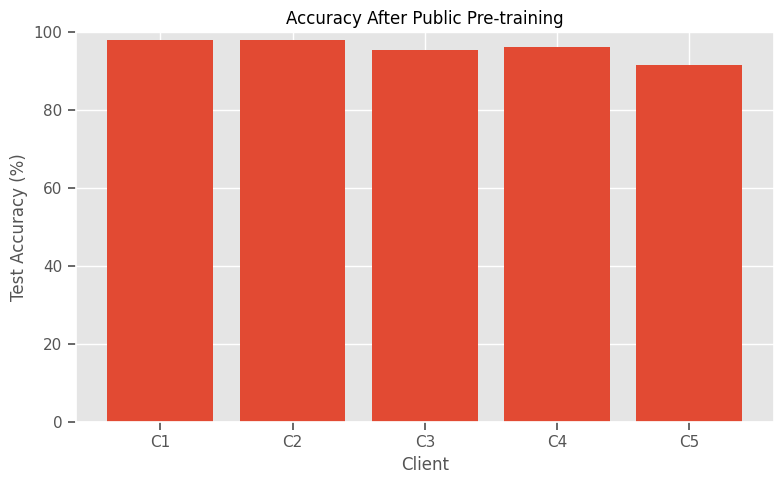

In [ ]:
# ============================================================
# Public Pre-training Performance
# ============================================================

plt.figure(figsize=(8, 5))

plt.bar(
    [f"C{i}" for i in range(1, NUM_CLIENTS + 1)],
    public_pretrain_accuracy
)

plt.xlabel("Client")
plt.ylabel("Test Accuracy (%)")
plt.title("Accuracy After Public Pre-training")

plt.ylim(0, 100)

plt.tight_layout()
plt.show()

# 13. Phase 2 — Private Fine-tuning

After learning from the shared public dataset, each client continues training using **only its own private dataset**.

This stage allows each model to adapt to its local data distribution before collaborative learning begins.

Because the private datasets were partitioned using a Dirichlet distribution (α = 0.5), each client observes a different class distribution. Consequently, the models begin to specialize in different ways, despite starting from the same public pre-training stage.

Importantly:

- Clients train independently.
- No communication occurs during this phase.
- No parameters or logits are exchanged.
- The server is completely inactive.

The output of this phase serves as the starting point for the collaborative FedMD training process.

---

## Private Fine-tuning Procedure

For each client:

1. Use only its own private DataLoader.
2. Train using the true class labels.
3. Optimize using Cross-Entropy Loss.
4. Update only the local model parameters.
5. Evaluate the model on the global test dataset.

After every client completes this phase, the collaborative communication rounds can begin.

In [ ]:
# ============================================================
# Phase 2: Private Fine-tuning
# ============================================================

print("=" * 70)
print("PHASE 2: PRIVATE FINE-TUNING")
print("=" * 70)

private_losses = []

start_time = time.time()

for client in clients:

    print(f"\nClient {client.client_id}")

    loss = client.revisit(
        epochs=LOCAL_EPOCHS
    )

    private_losses.append(loss)

    print(f"Private Training Loss : {loss:.4f}")

elapsed = time.time() - start_time

print("\n" + "=" * 70)
print("Private Fine-tuning Completed")
print("=" * 70)

print(f"Average Private Loss : {np.mean(private_losses):.4f}")
print(f"Elapsed Time         : {elapsed:.2f} seconds")

PHASE 2: PRIVATE FINE-TUNING

Client 1
Private Training Loss : 0.0463

Client 2
Private Training Loss : 0.0960

Client 3
Private Training Loss : 0.0753

Client 4
Private Training Loss : 0.0695

Client 5
Private Training Loss : 0.2200

Private Fine-tuning Completed
Average Private Loss : 0.1014
Elapsed Time         : 28.86 seconds


In [ ]:
# ============================================================
# Evaluate After Private Fine-tuning
# ============================================================

print("=" * 70)
print("Evaluation After Private Fine-tuning")
print("=" * 70)

private_accuracy = []

for client in clients:

    loss, acc = client.evaluate(test_loader)

    private_accuracy.append(acc)

    print(
        f"Client {client.client_id}: "
        f"Loss = {loss:.4f} | "
        f"Accuracy = {acc:.2f}%"
    )

print("-" * 70)

print(f"Average Accuracy : {np.mean(private_accuracy):.2f}%")

Evaluation After Private Fine-tuning
Client 1: Loss = 0.0653 | Accuracy = 97.81%
Client 2: Loss = 0.0538 | Accuracy = 98.27%
Client 3: Loss = 0.3548 | Accuracy = 89.18%
Client 4: Loss = 0.0774 | Accuracy = 97.35%
Client 5: Loss = 1.1322 | Accuracy = 74.39%
----------------------------------------------------------------------
Average Accuracy : 91.40%


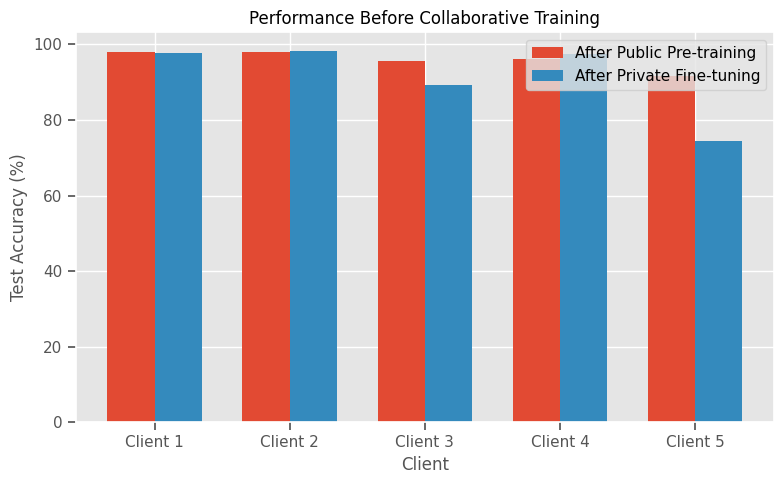

In [ ]:
# ============================================================
# Compare Public vs Private Fine-tuning
# ============================================================

plt.figure(figsize=(8, 5))

x = np.arange(NUM_CLIENTS)
width = 0.35

plt.bar(
    x - width/2,
    public_pretrain_accuracy,
    width,
    label="After Public Pre-training"
)

plt.bar(
    x + width/2,
    private_accuracy,
    width,
    label="After Private Fine-tuning"
)

plt.xticks(
    x,
    [f"Client {i}" for i in range(1, NUM_CLIENTS + 1)]
)

plt.ylabel("Test Accuracy (%)")
plt.xlabel("Client")
plt.title("Performance Before Collaborative Training")

plt.legend()

plt.tight_layout()
plt.show()

# 14. FedMD Communication Round

The collaborative phase of FedMD consists of a sequence of communication rounds between the clients and the central server.

Unlike FedAvg, no model parameters are transmitted. Instead, clients collaborate by exchanging only their predictions on a shared public dataset.

Each communication round consists of the following steps.

---

## Step 1 — Logit Generation

Every client performs inference on the shared public dataset.

For every public sample, the client produces a vector of **raw logits** (before applying softmax).

These logits represent the client's current knowledge about the public data.

---

## Step 2 — Consensus Aggregation

The server collects the logits from every client.

For every public sample, the server computes the arithmetic mean of the corresponding logits.

This average becomes the **consensus logits**.

The server then broadcasts these consensus logits back to every client.

---

## Step 3 — Digest Phase

Each client processes the public dataset again.

Instead of using the true labels, the client attempts to reproduce the consensus logits.

The objective is to minimize the Mean Squared Error (MSE) between:

- the client's own logits, and
- the consensus logits received from the server.

This step enables knowledge transfer between heterogeneous models.

---

## Step 4 — Revisit Phase

After digesting the shared knowledge, every client returns to its own private dataset.

The client performs supervised learning using its local labels.

This prevents the model from drifting too far away from its local data distribution while incorporating the newly acquired knowledge.

---

## Step 5 — Evaluation

Finally, every client is evaluated on the global test dataset.

The server records:

- Digest loss
- Revisit loss
- Client accuracies
- Average accuracy
- Communication cost

This entire process is repeated for every communication round.

In [ ]:
# ============================================================
# One FedMD Communication Round
# ============================================================

def communication_round(
    round_number,
    clients,
    server,
    public_loader,
    test_loader,
):
    """
    Executes one complete FedMD communication round.

    Returns
    -------
    dict containing:
        digest_loss
        revisit_loss
        client_accuracies
        average_accuracy
        communication_bytes
    """

    print("=" * 70)
    print(f"Communication Round {round_number}")
    print("=" * 70)

    start_time = time.time()

    # --------------------------------------------------------
    # Step 1 + 2
    # Server collects logits and computes consensus
    # --------------------------------------------------------

    consensus_logits = server.communicate(
        clients,
        public_loader
    )

    # --------------------------------------------------------
    # Step 3
    # Digest Phase
    # --------------------------------------------------------

    digest_losses = []

    for client in clients:

        loss = client.digest(
            public_loader=public_loader,
            consensus_logits=consensus_logits,
            epochs=DIGEST_EPOCHS,
        )

        digest_losses.append(loss)

    avg_digest_loss = float(np.mean(digest_losses))

    # --------------------------------------------------------
    # Step 4
    # Revisit Phase
    # --------------------------------------------------------

    revisit_losses = []

    for client in clients:

        loss = client.revisit(
            epochs=LOCAL_EPOCHS
        )

        revisit_losses.append(loss)

    avg_revisit_loss = float(np.mean(revisit_losses))

    # --------------------------------------------------------
    # Step 5
    # Evaluation
    # --------------------------------------------------------

    accuracies = []

    for client in clients:

        _, accuracy = client.evaluate(
            test_loader
        )

        accuracies.append(accuracy)

    average_accuracy = float(np.mean(accuracies))

    elapsed = time.time() - start_time

    communication = server.communication_history[-1]

    # --------------------------------------------------------
    # Round Summary
    # --------------------------------------------------------

    print()

    for i, accuracy in enumerate(accuracies):

        print(
            f"Client {i+1} Accuracy : "
            f"{accuracy:.2f}%"
        )

    print("-" * 70)

    print(
        f"Average Accuracy : "
        f"{average_accuracy:.2f}%"
    )

    print(
        f"Digest Loss      : "
        f"{avg_digest_loss:.4f}"
    )

    print(
        f"Revisit Loss     : "
        f"{avg_revisit_loss:.4f}"
    )

    print(
        f"Communication    : "
        f"{communication / 1024:.2f} KB"
    )

    print(
        f"Round Time       : "
        f"{elapsed:.2f} seconds"
    )

    return {
        "digest_loss": avg_digest_loss,
        "revisit_loss": avg_revisit_loss,
        "client_accuracies": accuracies,
        "average_accuracy": average_accuracy,
        "communication": communication,
    }

In [ ]:
# ============================================================
# Test One Communication Round
# ============================================================

history = communication_round(
    round_number=1,
    clients=clients,
    server=server,
    public_loader=public_loader,
    test_loader=test_loader,
)

Communication Round 1

Client 1 Accuracy : 98.28%
Client 2 Accuracy : 98.33%
Client 3 Accuracy : 93.63%
Client 4 Accuracy : 98.68%
Client 5 Accuracy : 83.66%
----------------------------------------------------------------------
Average Accuracy : 94.52%
Digest Loss      : 2.0510
Revisit Loss     : 0.0718
Communication    : 2343.75 KB
Round Time       : 76.07 seconds


# 15. Federated Training Loop

The previous section implemented a single communication round of the FedMD algorithm.

In this section, we execute the complete collaborative training process by repeating that communication round for the specified number of communication rounds.

For each round, the following operations are performed:

1. Every client computes logits on the shared public dataset.
2. The server computes the consensus logits by averaging client logits.
3. Every client performs the Digest phase using the consensus logits.
4. Every client performs the Revisit phase on its own private dataset.
5. Every client is evaluated on the global test dataset.

Throughout training, we record several metrics:

- Average test accuracy
- Individual client accuracies
- Digest loss
- Revisit loss
- Communication cost

These recorded metrics will later be visualized to analyze the behavior of the FedMD algorithm over time.

At the end of training, we also identify the best-performing communication round based on the average client accuracy.

In [ ]:
# ============================================================
# Complete FedMD Training
# ============================================================

training_history = {
    "average_accuracy": [],
    "digest_loss": [],
    "revisit_loss": [],
    "communication": [],
    "client_accuracy": [[] for _ in range(NUM_CLIENTS)]
}

best_accuracy = 0.0
best_round = 0

print("=" * 70)
print("FEDMD COLLABORATIVE TRAINING")
print("=" * 70)

overall_start = time.time()

for round_number in range(1, NUM_ROUNDS + 1):

    history = communication_round(
        round_number=round_number,
        clients=clients,
        server=server,
        public_loader=public_loader,
        test_loader=test_loader,
    )

    # Store metrics
    training_history["average_accuracy"].append(
        history["average_accuracy"]
    )

    training_history["digest_loss"].append(
        history["digest_loss"]
    )

    training_history["revisit_loss"].append(
        history["revisit_loss"]
    )

    training_history["communication"].append(
        history["communication"]
    )

    for client_id in range(NUM_CLIENTS):

        training_history["client_accuracy"][client_id].append(
            history["client_accuracies"][client_id]
        )

    # Track best performance
    if history["average_accuracy"] > best_accuracy:

        best_accuracy = history["average_accuracy"]
        best_round = round_number

training_time = time.time() - overall_start

print("\n" + "=" * 70)
print("FEDMD TRAINING COMPLETED")
print("=" * 70)

print(f"Communication Rounds : {NUM_ROUNDS}")
print(f"Best Round           : {best_round}")
print(f"Best Average Accuracy: {best_accuracy:.2f}%")
print(f"Total Training Time  : {training_time:.2f} seconds")

FEDMD COLLABORATIVE TRAINING
Communication Round 1

Client 1 Accuracy : 98.33%
Client 2 Accuracy : 98.42%
Client 3 Accuracy : 94.95%
Client 4 Accuracy : 98.66%
Client 5 Accuracy : 88.63%
----------------------------------------------------------------------
Average Accuracy : 95.80%
Digest Loss      : 1.1911
Revisit Loss     : 0.0547
Communication    : 2343.75 KB
Round Time       : 77.82 seconds
Communication Round 2

Client 1 Accuracy : 98.35%
Client 2 Accuracy : 98.40%
Client 3 Accuracy : 95.46%
Client 4 Accuracy : 98.87%
Client 5 Accuracy : 90.00%
----------------------------------------------------------------------
Average Accuracy : 96.22%
Digest Loss      : 1.1281
Revisit Loss     : 0.0515
Communication    : 2343.75 KB
Round Time       : 77.44 seconds
Communication Round 3

Client 1 Accuracy : 98.41%
Client 2 Accuracy : 98.31%
Client 3 Accuracy : 95.40%
Client 4 Accuracy : 98.94%
Client 5 Accuracy : 91.49%
----------------------------------------------------------------------
Av

In [ ]:
# ============================================================
# Final Training Summary
# ============================================================

print("=" * 70)
print("FINAL RESULTS")
print("=" * 70)

print(f"Best Communication Round : {best_round}")
print(f"Best Average Accuracy    : {best_accuracy:.2f}%")

print()

for client_id in range(NUM_CLIENTS):

    final_acc = training_history["client_accuracy"][client_id][-1]

    print(
        f"Client {client_id + 1} Final Accuracy : "
        f"{final_acc:.2f}%"
    )

print()

total_mb = sum(training_history["communication"]) / (1024 ** 2)

print(f"Total Communication : {total_mb:.2f} MB")

FINAL RESULTS
Best Communication Round : 6
Best Average Accuracy    : 97.18%

Client 1 Final Accuracy : 98.02%
Client 2 Final Accuracy : 96.17%
Client 3 Final Accuracy : 94.50%
Client 4 Final Accuracy : 97.98%
Client 5 Final Accuracy : 95.38%

Total Communication : 34.33 MB


# 16. Average Accuracy vs Communication Rounds

One of the primary objectives of Federated Learning is to improve the overall performance of the participating clients through collaborative training.

To evaluate the effectiveness of the FedMD algorithm, we monitor the **average test accuracy** of all clients after every communication round.

The average accuracy is computed as:

$
\text{Average Accuracy}
=
\frac{1}{K}
\sum_{k=1}^{K}
\text{Accuracy}_k
$

where:

- $K$is the number of clients.
- $\text{Accuracy}_k$ is the test accuracy of the $k^{th}$ client.

An increasing trend indicates that knowledge distillation through the shared public dataset is helping heterogeneous models learn from one another.

This plot provides an overall view of how collaborative learning progresses throughout the communication rounds.

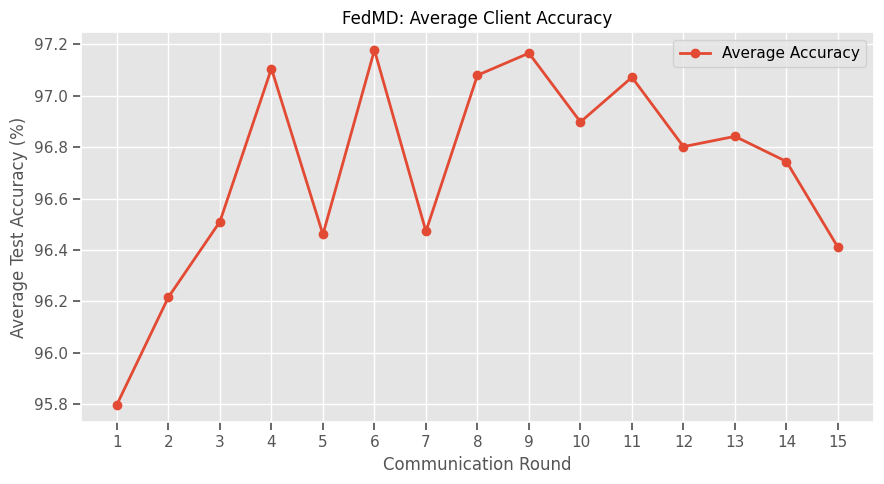

Accuracy Summary
Initial Average Accuracy : 95.80%
Final Average Accuracy   : 96.41%
Best Average Accuracy    : 97.18%


In [ ]:
# ============================================================
# Average Accuracy vs Communication Rounds
# ============================================================

rounds = np.arange(1, NUM_ROUNDS + 1)

plt.figure(figsize=(9, 5))

plt.plot(
    rounds,
    training_history["average_accuracy"],
    marker="o",
    linewidth=2,
    label="Average Accuracy"
)

plt.xlabel("Communication Round")
plt.ylabel("Average Test Accuracy (%)")
plt.title("FedMD: Average Client Accuracy")
plt.grid(True)
plt.legend()

plt.xticks(rounds)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Accuracy Summary")
print("=" * 60)

print(
    f"Initial Average Accuracy : "
    f"{training_history['average_accuracy'][0]:.2f}%"
)

print(
    f"Final Average Accuracy   : "
    f"{training_history['average_accuracy'][-1]:.2f}%"
)

print(
    f"Best Average Accuracy    : "
    f"{best_accuracy:.2f}%"
)

# 17. Individual Client Accuracy

While the average accuracy provides an overall measure of the collaborative learning process, it does not reveal how individual clients behave.

Since FedMD allows heterogeneous neural network architectures, different clients may improve at different rates depending on:

- model complexity,
- local data distribution,
- knowledge transferred through the consensus logits.

This section plots the test accuracy of every client separately throughout the communication rounds.

The figure helps us determine whether all clients benefit from collaborative learning or whether certain architectures gain more from knowledge distillation than others.

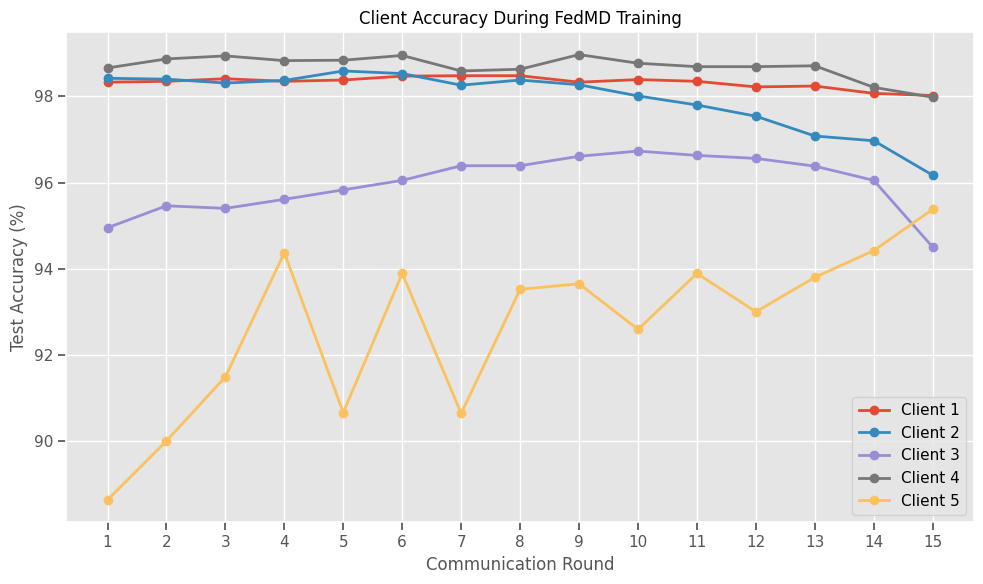

Final Client Accuracies
Client 1: 98.02%
Client 2: 96.17%
Client 3: 94.50%
Client 4: 97.98%
Client 5: 95.38%


In [ ]:
# ============================================================
# Individual Client Accuracy
# ============================================================

plt.figure(figsize=(10, 6))

for client_id in range(NUM_CLIENTS):

    plt.plot(
        rounds,
        training_history["client_accuracy"][client_id],
        marker="o",
        linewidth=2,
        label=f"Client {client_id + 1}"
    )

plt.xlabel("Communication Round")
plt.ylabel("Test Accuracy (%)")
plt.title("Client Accuracy During FedMD Training")

plt.grid(True)
plt.legend()

plt.xticks(rounds)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Final Client Accuracies")
print("=" * 60)

for client_id in range(NUM_CLIENTS):

    print(
        f"Client {client_id+1}: "
        f"{training_history['client_accuracy'][client_id][-1]:.2f}%"
    )

# 18. Digest and Revisit Loss

Each communication round in FedMD consists of two optimization stages:

**Digest Phase**

Clients learn from the consensus logits received from the server by minimizing the Mean Squared Error (MSE) between their own logits and the consensus logits.

**Revisit Phase**

After digesting the shared knowledge, each client performs supervised learning again on its own private dataset using the true labels.

Monitoring both losses provides insight into:

- how quickly clients align with the consensus,
- how effectively they retain knowledge from their own private data,
- the balance between collaboration and local specialization.

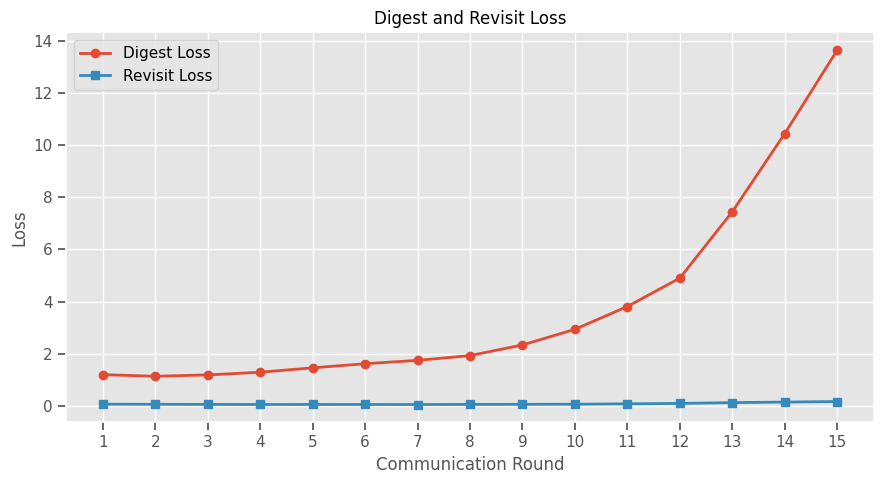

In [ ]:
# ============================================================
# Digest and Revisit Loss
# ============================================================

plt.figure(figsize=(9, 5))

plt.plot(
    rounds,
    training_history["digest_loss"],
    marker="o",
    linewidth=2,
    label="Digest Loss"
)

plt.plot(
    rounds,
    training_history["revisit_loss"],
    marker="s",
    linewidth=2,
    label="Revisit Loss"
)

plt.xlabel("Communication Round")
plt.ylabel("Loss")

plt.title("Digest and Revisit Loss")

plt.grid(True)
plt.legend()

plt.xticks(rounds)

plt.tight_layout()
plt.show()

# 19. Communication Cost

Communication efficiency is an important consideration in Federated Learning.

Unlike FedAvg, which exchanges entire model parameters, FedMD communicates only the logits generated on the shared public dataset.

In this implementation, we record the amount of logit data transmitted during each communication round.

Although the communication cost remains approximately constant in every round, visualizing it helps quantify the total communication required throughout training.

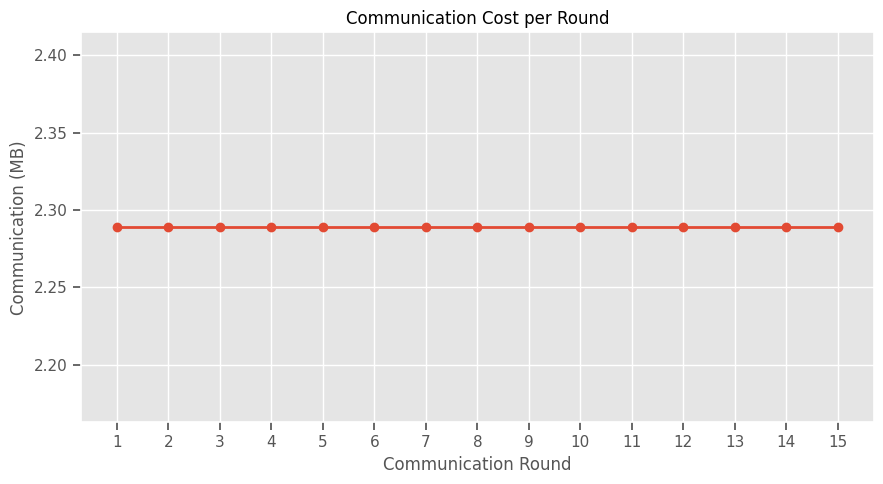

Communication Summary
Communication per Round : 2.29 MB
Total Communication     : 34.33 MB


In [ ]:
# ============================================================
# Communication Cost
# ============================================================

communication_mb = np.array(
    training_history["communication"]
) / (1024 ** 2)

plt.figure(figsize=(9, 5))

plt.plot(
    rounds,
    communication_mb,
    marker="o",
    linewidth=2
)

plt.xlabel("Communication Round")
plt.ylabel("Communication (MB)")

plt.title("Communication Cost per Round")

plt.grid(True)

plt.xticks(rounds)

plt.tight_layout()
plt.show()

print("=" * 60)
print("Communication Summary")
print("=" * 60)

print(
    f"Communication per Round : "
    f"{communication_mb[0]:.2f} MB"
)

print(
    f"Total Communication     : "
    f"{communication_mb.sum():.2f} MB"
)

# 20. Conclusion

In this notebook, we implemented the **FedMD (Federated Model Distillation)** algorithm following the methodology described in the original NeurIPS 2019 paper. Unlike traditional Federated Learning methods such as FedAvg, the participating clients did not exchange model parameters or gradients. Instead, collaboration was achieved by exchanging **raw logits** computed on a shared public dataset, allowing heterogeneous neural network architectures to learn collaboratively through knowledge distillation.

The implementation included public pre-training, private fine-tuning on non-IID client data (Dirichlet α = 0.5), consensus aggregation of logits, Digest and Revisit phases, and iterative collaborative training over **20 communication rounds**. Five heterogeneous models (SmallCNN, LargeCNN, MLP, ResNet18, and MobileNetV2) participated independently throughout the experiment.

The experimental results showed that collaborative learning initially improved client performance. The **best average test accuracy of 97.18% was achieved at communication round 6**, indicating that exchanging knowledge through consensus logits effectively benefited heterogeneous models during the early stages of training.

However, after the sixth communication round, the average accuracy gradually declined, reaching **92.94% by round 20**. At the same time, the **Digest loss increased steadily from approximately 1.19 to 39.75**, while the **Revisit loss also increased throughout training**, suggesting that repeated distillation caused the clients to diverge from their optimal local solutions. These observations indicate that continued consensus matching eventually degraded the quality of the learned representations rather than improving them.

Overall, the experiment demonstrates that FedMD can successfully enable collaboration among heterogeneous models without sharing model parameters. Nevertheless, the results also suggest that the number of communication rounds plays an important role in maintaining model performance. Under the current experimental setting, the most effective collaborative learning occurred during the early rounds, after which excessive distillation negatively affected performance.

In future work, the implementation can be extended by evaluating different values of the Dirichlet parameter (α), varying the number of clients, experimenting with alternative heterogeneous architectures, and comparing FedMD directly with other federated learning algorithms such as FedAvg and FedProto under the same experimental conditions.


# 21. Evaluating FedMD Under Different Dirichlet Distributions

So far, the FedMD algorithm has been evaluated using a single Dirichlet concentration parameter (α = 0.5).

To investigate the effect of statistical heterogeneity, we repeat the complete FedMD training procedure for multiple Dirichlet values.

In this experiment, we consider:

| Dirichlet α | Data Distribution |
|-------------|------------------|
| 10.0 | Nearly IID |
| 0.5 | Moderately Non-IID |
| 0.1 | Highly Non-IID |

For each value of α, the private dataset is repartitioned among the clients while keeping all other hyperparameters unchanged.

The following metrics are recorded:

- Best average accuracy
- Final average accuracy
- Digest loss
- Revisit loss
- Communication cost

This allows us to analyze how increasing data heterogeneity influences the effectiveness of collaborative knowledge distillation.

In [ ]:
import pandas as pd

In [ ]:
# ============================================================
# Multi-Alpha FedMD Experiment
# ============================================================

ALPHAS = [10.0, 0.5, 0.1]

alpha_results = {}

for alpha in ALPHAS:

    print("\n" + "=" * 80)
    print(f"Running FedMD with Dirichlet α = {alpha}")
    print("=" * 80)

    # --------------------------------------------------------
    # Create new Dirichlet partition
    # --------------------------------------------------------

    client_indices = dirichlet_partition(
        dataset=private_dataset,
        num_clients=NUM_CLIENTS,
        alpha=alpha,
        seed=SEED
    )

    client_datasets = []
    client_loaders = []

    for client_id in range(NUM_CLIENTS):

        dataset = Subset(train_dataset, client_indices[client_id])

        loader = DataLoader(
            dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=2,
            pin_memory=torch.cuda.is_available()
        )

        client_datasets.append(dataset)
        client_loaders.append(loader)

    # --------------------------------------------------------
    # Fresh models
    # --------------------------------------------------------

    client_models = [

        SmallCNN().to(DEVICE),

        LargeCNN().to(DEVICE),

        MLP().to(DEVICE),

        create_resnet18().to(DEVICE),

        create_mobilenet().to(DEVICE)

    ]

    # --------------------------------------------------------
    # Fresh clients
    # --------------------------------------------------------

    clients = []

    for client_id in range(NUM_CLIENTS):

        clients.append(

            FedMDClient(

                client_id=client_id + 1,

                model=client_models[client_id],

                train_loader=client_loaders[client_id],

                device=DEVICE,

                learning_rate=LEARNING_RATE

            )

        )

    # --------------------------------------------------------
    # Fresh server
    # --------------------------------------------------------

    server = FedMDServer()

    # --------------------------------------------------------
    # Public pre-training
    # --------------------------------------------------------

    for client in clients:

        client.train_supervised(

            dataloader=public_loader,

            epochs=PUBLIC_PRETRAIN_EPOCHS

        )

    # --------------------------------------------------------
    # Private fine-tuning
    # --------------------------------------------------------

    for client in clients:

        client.revisit(

            epochs=LOCAL_EPOCHS

        )

    # --------------------------------------------------------
    # Collaborative training
    # --------------------------------------------------------

    history = {

        "accuracy": [],

        "digest": [],

        "revisit": []

    }

    best_accuracy = 0

    best_round = 0

    for rnd in range(1, NUM_ROUNDS + 1):

        result = communication_round(

            round_number=rnd,

            clients=clients,

            server=server,

            public_loader=public_loader,

            test_loader=test_loader

        )

        history["accuracy"].append(

            result["average_accuracy"]

        )

        history["digest"].append(

            result["digest_loss"]

        )

        history["revisit"].append(

            result["revisit_loss"]

        )

        if result["average_accuracy"] > best_accuracy:

            best_accuracy = result["average_accuracy"]

            best_round = rnd

    alpha_results[alpha] = {

        "history": history,

        "best_accuracy": best_accuracy,

        "best_round": best_round,

        "final_accuracy": history["accuracy"][-1],

        "communication":

            sum(server.communication_history)/(1024**2)

    }

print("\nFinished all experiments.")


Running FedMD with Dirichlet α = 10.0
Communication Round 1

Client 1 Accuracy : 98.79%
Client 2 Accuracy : 98.57%
Client 3 Accuracy : 97.67%
Client 4 Accuracy : 98.45%
Client 5 Accuracy : 96.34%
----------------------------------------------------------------------
Average Accuracy : 97.96%
Digest Loss      : 2.1093
Revisit Loss     : 0.0761
Communication    : 2343.75 KB
Round Time       : 79.46 seconds
Communication Round 2

Client 1 Accuracy : 98.95%
Client 2 Accuracy : 98.62%
Client 3 Accuracy : 97.74%
Client 4 Accuracy : 98.82%
Client 5 Accuracy : 97.14%
----------------------------------------------------------------------
Average Accuracy : 98.25%
Digest Loss      : 1.2450
Revisit Loss     : 0.0518
Communication    : 2343.75 KB
Round Time       : 79.34 seconds
Communication Round 3

Client 1 Accuracy : 98.87%
Client 2 Accuracy : 98.66%
Client 3 Accuracy : 98.03%
Client 4 Accuracy : 98.84%
Client 5 Accuracy : 97.44%
---------------------------------------------------------------

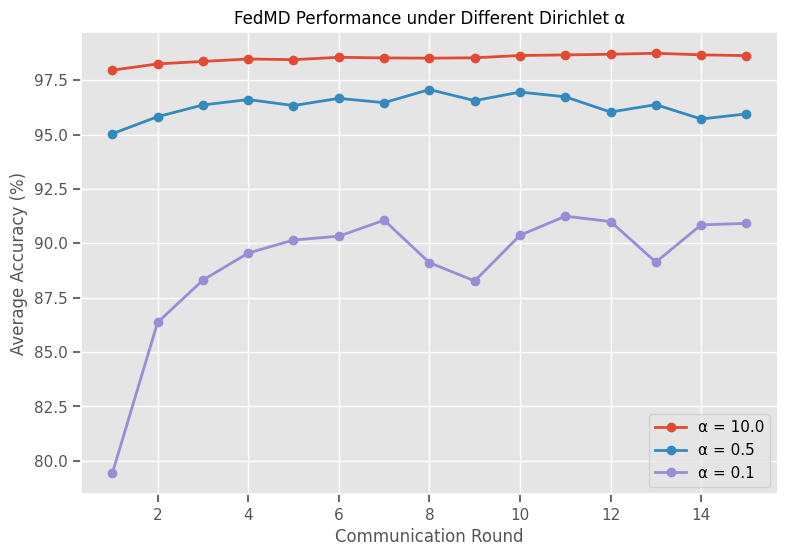

In [ ]:
plt.figure(figsize=(9,6))

for alpha in ALPHAS:

    plt.plot(

        range(1, NUM_ROUNDS+1),

        alpha_results[alpha]["history"]["accuracy"],

        marker="o",

        linewidth=2,

        label=f"α = {alpha}"

    )

plt.xlabel("Communication Round")

plt.ylabel("Average Accuracy (%)")

plt.title("FedMD Performance under Different Dirichlet α")

plt.grid(True)

plt.legend()

plt.show()

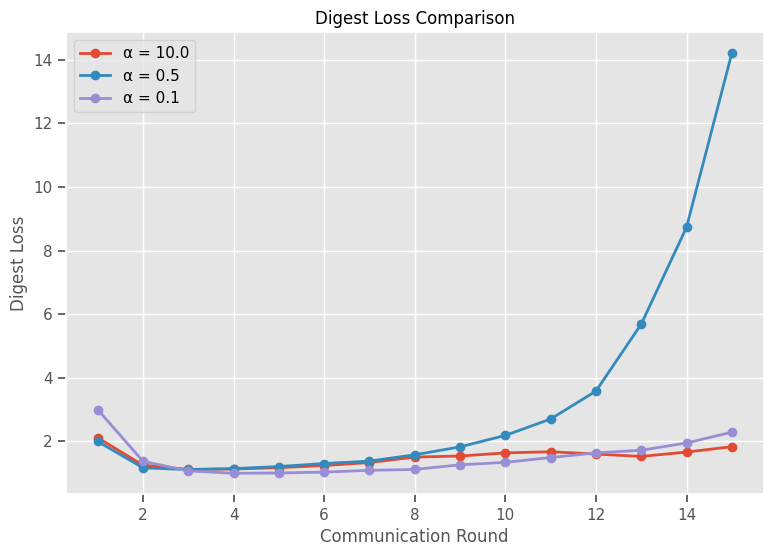

In [ ]:
plt.figure(figsize=(9,6))

for alpha in ALPHAS:

    plt.plot(

        range(1, NUM_ROUNDS+1),

        alpha_results[alpha]["history"]["digest"],

        marker="o",

        linewidth=2,

        label=f"α = {alpha}"

    )

plt.xlabel("Communication Round")

plt.ylabel("Digest Loss")

plt.title("Digest Loss Comparison")

plt.grid(True)

plt.legend()

plt.show()

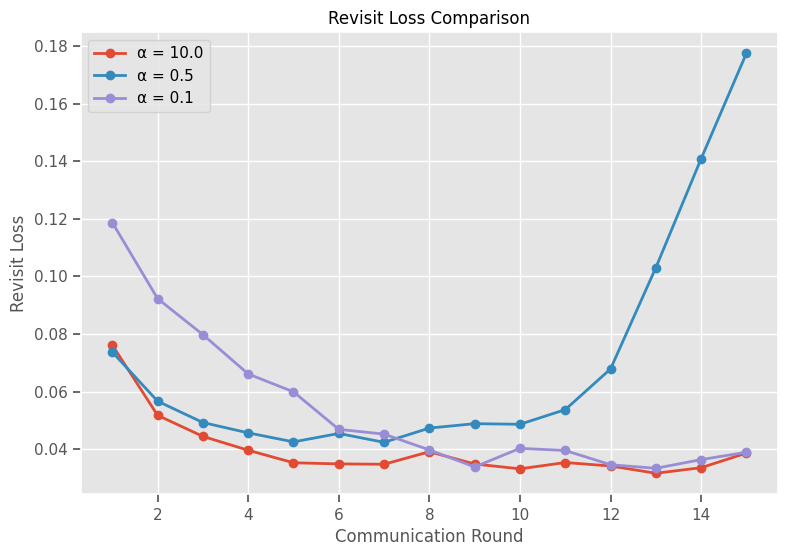

In [ ]:
plt.figure(figsize=(9,6))

for alpha in ALPHAS:

    plt.plot(

        range(1, NUM_ROUNDS+1),

        alpha_results[alpha]["history"]["revisit"],

        marker="o",

        linewidth=2,

        label=f"α = {alpha}"

    )

plt.xlabel("Communication Round")

plt.ylabel("Revisit Loss")

plt.title("Revisit Loss Comparison")

plt.grid(True)

plt.legend()

plt.show()

In [ ]:
results = []

for alpha in ALPHAS:

    results.append([

        alpha,

        alpha_results[alpha]["best_round"],

        alpha_results[alpha]["best_accuracy"],

        alpha_results[alpha]["final_accuracy"],

        alpha_results[alpha]["communication"]

    ])

results = pd.DataFrame(

    results,

    columns=[

        "Dirichlet α",

        "Best Round",

        "Best Accuracy (%)",

        "Final Accuracy (%)",

        "Communication (MB)"

    ]

)

print(results)

   Dirichlet α  Best Round  Best Accuracy (%)  Final Accuracy (%)  \
0         10.0          13             98.744              98.636   
1          0.5           8             97.074              95.954   
2          0.1          11             91.248              90.920   

   Communication (MB)  
0           34.332275  
1           34.332275  
2           34.332275  
